# 2 · Modelagem — Uplift para direcionamento de ofertas (iFood)

**Pergunta:** para cada cliente, *qual oferta enviar* (e se vale a pena enviar)?

Modelamos o **efeito incremental** (uplift) de expor o cliente à oferta, e não a
mera propensão a completar. Assim separamos:

| Segmento | Comportamento | Ação ótima |
|---|---|---|
| **Persuadíveis** | completam **se** virem a oferta | **enviar** (valor incremental) |
| **Certeza (sure things)** | completam de qualquer jeito | **não enviar** (recompensa desperdiçada) |
| **Causa perdida** | não completam nem vendo | não enviar |

**Tratamento** `W` = oferta visualizada na validade · **Desfecho** `Y` = oferta
completada (bogo/discount) ou transação (informational).

**Modelo:** *T-learner* (dois modelos, tratado vs controle) com XGBoost;
`uplift(x) = P(Y|x,W=1) − P(Y|x,W=0)`. Comparado a um *S-learner* (baseline).
**Avaliação:** curva de uplift/Qini, Qini-AUC e uplift@k — as métricas corretas
para direcionamento, pois medem ganho incremental por fração da base atingida.


## Setup e carga

In [1]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier
from src.config import MODELING_TABLE_PARQUET, OFFERS_PARQUET, PRESENTATION
from src.uplift_metrics import uplift_by_percentile, qini_curve, qini_auc, uplift_at_k

FIG = PRESENTATION / "figures"; FIG.mkdir(parents=True, exist_ok=True)
IFOOD_RED = "#EA1D2C"

df = pd.read_parquet(MODELING_TABLE_PARQUET)
offers = pd.read_parquet(OFFERS_PARQUET)
print("modeling_table:", df.shape)
df.head(3)

modeling_table: (76277, 28)


,instance_id,account_id,offer_id,offer_type,min_value,discount_value,duration,n_channels,ch_web,ch_email,...,total_spend,avg_ticket,active_days,last_tx_day,W,Y,completed,spend_window,reward_paid,t_recv
0,6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5.0,4,1,1,...,4.09,1.36,2,19.75,1,0,0,0.00,0.0,7.0
1,7,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5.0,4,1,1,...,4.09,1.36,2,19.75,1,0,0,0.00,0.0,24.0
2,46,0056df74b63b4298809f0b375a304cf4,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,7,3,7.0,4,1,1,...,144.14,28.83,5,28.00,1,1,1,59.66,3.0,24.0


## 1. Análise exploratória orientada ao negócio

### 1.1 Funil de ofertas e recompensa desperdiçada
O ponto central: parte das ofertas é **completada sem ter sido vista** — o cliente
compraria de qualquer forma, e a recompensa é dinheiro jogado fora.

Ofertas bogo/discount: 61,042
  Completou vendo (persuadível/ok)   :  45.7%
  Completou SEM ver (desperdício)    :   9.4%
  Viu e não completou                :  31.2%
  Não viu e não completou            :  13.7%


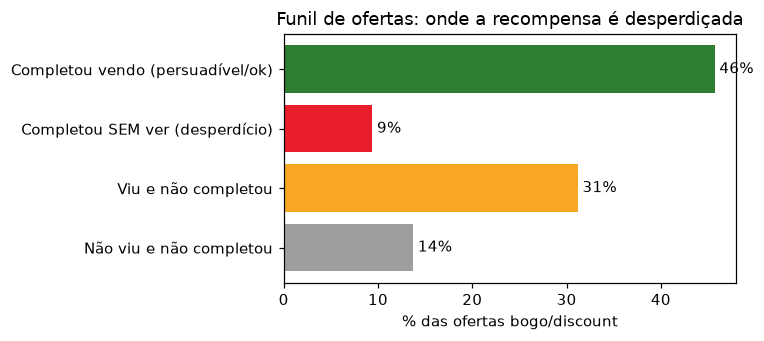

In [2]:
bd = df[df.offer_type.isin(['bogo','discount'])].copy()
n = len(bd)
seg = {
 'Completou vendo (persuadível/ok)': ((bd.completed==1)&(bd.W==1)).mean(),
 'Completou SEM ver (desperdício)' : ((bd.completed==1)&(bd.W==0)).mean(),
 'Viu e não completou'             : ((bd.W==1)&(bd.completed==0)).mean(),
 'Não viu e não completou'         : ((bd.W==0)&(bd.completed==0)).mean(),
}
print("Ofertas bogo/discount:", f"{n:,}")
for k,v in seg.items(): print(f"  {k:35s}: {v:6.1%}")

fig, ax = plt.subplots(figsize=(7,3.2))
colors = ['#2E7D32', IFOOD_RED, '#F9A825', '#9E9E9E']
ax.barh(list(seg.keys())[::-1], [v*100 for v in list(seg.values())[::-1]], color=colors[::-1])
ax.set_xlabel('% das ofertas bogo/discount'); ax.set_title('Funil de ofertas: onde a recompensa é desperdiçada')
for i,v in enumerate(list(seg.values())[::-1]): ax.text(v*100+0.5, i, f'{v:.0%}', va='center')
plt.tight_layout(); plt.savefig(FIG/'01_funnel.png', bbox_inches='tight'); plt.show()

### 1.2 Uplift naïve por tipo de oferta e por segmento de cliente

Uplift naïve (completar | viu - não viu):
offer_type
bogo        0.079
discount    0.291
dtype: float64


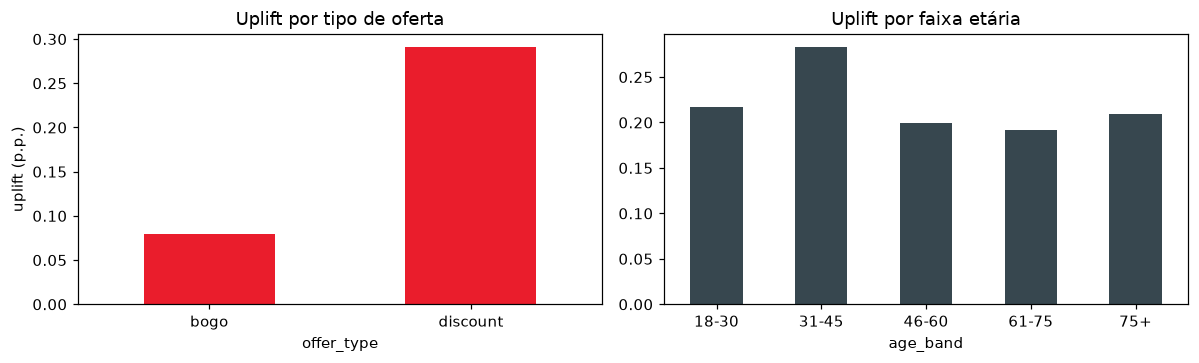

In [3]:
def naive_uplift(g):
    t,ctrl = g[g.W==1], g[g.W==0]
    return (t.completed.mean() if len(t) else np.nan) - (ctrl.completed.mean() if len(ctrl) else np.nan)

by_type = bd.groupby('offer_type').apply(naive_uplift).round(3)
print("Uplift naïve (completar | viu - não viu):"); print(by_type)

bd['age_band'] = pd.cut(bd.age, [17,30,45,60,75,120], labels=['18-30','31-45','46-60','61-75','75+'])
fig, axes = plt.subplots(1,2, figsize=(11,3.4))
by_type.plot.bar(ax=axes[0], color=IFOOD_RED); axes[0].set_title('Uplift por tipo de oferta'); axes[0].set_ylabel('uplift (p.p.)'); axes[0].tick_params(axis='x', rotation=0)
bd.groupby('age_band').apply(naive_uplift).plot.bar(ax=axes[1], color='#37474F'); axes[1].set_title('Uplift por faixa etária'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIG/'02_uplift_segments.png', bbox_inches='tight'); plt.show()

## 2. Preparação para modelagem
Escopo do uplift: ofertas **bogo/discount** (economia de recompensa clara).
Excluímos variáveis que são desfecho (evita vazamento). *Split por cliente*
(`GroupShuffleSplit`) para o mesmo cliente não vazar treino↔teste.

In [4]:
LEAK = ['completed','spend_window','reward_paid','n_tx_window','Y','W',
        'instance_id','account_id','offer_id','t_recv','last_tx_day']
num = ['min_value','discount_value','duration','n_channels','ch_web','ch_email',
       'ch_mobile','ch_social','age','credit_card_limit','tenure_days',
       'incomplete_profile','n_transactions','total_spend','avg_ticket','active_days']
data = bd.copy()
data['is_discount'] = (data.offer_type=='discount').astype(int)   # bogo=0
data['gender_M'] = (data.gender=='M').astype(int)
data['gender_F'] = (data.gender=='F').astype(int)
feat = num + ['is_discount','gender_M','gender_F']
# imputação simples de idade/limite ausentes (perfis incompletos)
data['age'] = data['age'].fillna(data['age'].median())
data['credit_card_limit'] = data['credit_card_limit'].fillna(0.0)

X = data[feat]; W = data['W'].values; y = data['completed'].values; groups = data['account_id'].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(gss.split(X, y, groups))
print("treino:", len(tr), "| teste:", len(te), "| clientes treino/teste:",
      data.iloc[tr].account_id.nunique(), "/", data.iloc[te].account_id.nunique())

treino: 45816 | teste: 15226 | clientes treino/teste: 12696 / 4232


## 3. T-learner (dois modelos: tratado vs controle)

In [5]:
def make_clf():
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                         random_state=42, n_jobs=-1)

Xtr, Xte = X.iloc[tr], X.iloc[te]
Wtr, Wte = W[tr], W[te]
ytr, yte = y[tr], y[te]

m_t = make_clf().fit(Xtr[Wtr==1], ytr[Wtr==1])   # tratados (viram)
m_c = make_clf().fit(Xtr[Wtr==0], ytr[Wtr==0])   # controle (não viram)
uplift_t = m_t.predict_proba(Xte)[:,1] - m_c.predict_proba(Xte)[:,1]
print("uplift previsto (teste): média %.3f | min %.3f | max %.3f"
      % (uplift_t.mean(), uplift_t.min(), uplift_t.max()))

uplift previsto (teste): média 0.098 | min -0.421 | max 0.629


### Baseline S-learner (um modelo com W como feature)

In [6]:
Xtr_s = Xtr.copy(); Xtr_s['W'] = Wtr
m_s = make_clf().fit(Xtr_s, ytr)
X1 = Xte.copy(); X1['W']=1; X0 = Xte.copy(); X0['W']=0
uplift_s = m_s.predict_proba(X1)[:,1] - m_s.predict_proba(X0)[:,1]
print("S-learner uplift médio:", round(uplift_s.mean(),3))

S-learner uplift médio: 0.091


## 4. Avaliação (métricas de uplift)
Qini-AUC mede o ganho incremental acumulado acima do aleatório; uplift@k é o
uplift real capturado ao mirar os top-k% mais bem ranqueados.

In [7]:
def evaluate(name, up):
    q = qini_auc(yte, Wte, up)
    print(f"{name:10s} | Qini-AUC {q:8.1f} | uplift@10% {uplift_at_k(yte,Wte,up,.1):.3f}"
          f" | uplift@30% {uplift_at_k(yte,Wte,up,.3):.3f} | uplift@50% {uplift_at_k(yte,Wte,up,.5):.3f}")
    return q
q_t = evaluate('T-learner', uplift_t)
q_s = evaluate('S-learner', uplift_s)
q_r = evaluate('Aleatório', np.random.RandomState(0).rand(len(uplift_t)))

T-learner  | Qini-AUC    321.9 | uplift@10% 0.298 | uplift@30% 0.263 | uplift@50% 0.244
S-learner  | Qini-AUC    175.9 | uplift@10% 0.250 | uplift@30% 0.217 | uplift@50% 0.217
Aleatório  | Qini-AUC     30.6 | uplift@10% 0.221 | uplift@30% 0.193 | uplift@50% 0.198


In [8]:
# Tabela de decis (T-learner) — uplift deve decrescer do decil 1 ao 10
dec = uplift_by_percentile(yte, Wte, uplift_t, bins=10)
print(dec[['decile','n','resp_treated','resp_control','uplift']].round(3).to_string(index=False))

 decile    n  resp_treated  resp_control  uplift
      1 1523         0.735         0.437   0.298
      2 1523         0.761         0.541   0.220
      3 1522         0.801         0.532   0.269
      4 1523         0.793         0.592   0.201
      5 1522         0.754         0.529   0.225
      6 1523         0.710         0.410   0.300
      7 1522         0.682         0.311   0.371
      8 1523         0.405         0.200   0.205
      9 1522         0.043         0.052  -0.009
     10 1523         0.376         0.471  -0.095


### Curva de uplift/Qini

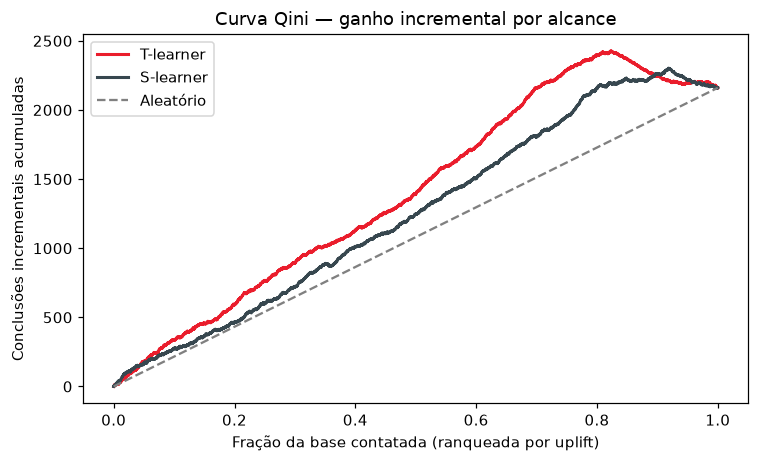

In [9]:
fig, ax = plt.subplots(figsize=(7,4.3))
for name, up, col in [('T-learner',uplift_t,IFOOD_RED),('S-learner',uplift_s,'#37474F')]:
    x,yq = qini_curve(yte, Wte, up); ax.plot(x, yq, label=f'{name}', color=col, lw=2)
xr,yr = qini_curve(yte, Wte, np.random.RandomState(0).rand(len(uplift_t)))
ax.plot([0,1],[0,yq[-1]], '--', color='grey', label='Aleatório')
ax.set_xlabel('Fração da base contatada (ranqueada por uplift)')
ax.set_ylabel('Conclusões incrementais acumuladas')
ax.set_title('Curva Qini — ganho incremental por alcance'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'03_qini.png', bbox_inches='tight'); plt.show()

## 5. Política de recomendação: qual oferta enviar a cada cliente
Para cada cliente do teste, pontuamos o uplift contra **cada oferta candidata**
(bogo/discount) e recomendamos a de maior uplift (só enviamos se uplift > 0).

In [10]:
cand = offers[offers.offer_type.isin(['bogo','discount'])].copy()
cust = data.iloc[te].drop_duplicates('account_id')
cust_feat = ['age','credit_card_limit','tenure_days','incomplete_profile',
             'n_transactions','total_spend','avg_ticket','active_days','gender_M','gender_F']
base = cust[['account_id']+cust_feat].reset_index(drop=True)

def score_offer(row):
    G = base.copy()
    G['min_value']=row.min_value; G['discount_value']=row.discount_value; G['duration']=row.duration
    G['n_channels']=row.n_channels
    for ch in ['web','email','mobile','social']: G['ch_'+ch]=row['ch_'+ch]
    G['is_discount']=int(row.offer_type=='discount')
    return m_t.predict_proba(G[feat])[:,1]-m_c.predict_proba(G[feat])[:,1]

scores = pd.DataFrame({r.offer_id: score_offer(r) for _,r in cand.iterrows()}, index=base.account_id)
best_offer = scores.idxmax(axis=1); best_uplift = scores.max(axis=1)
reco = pd.DataFrame({'account_id':scores.index,'best_offer':best_offer.values,'best_uplift':best_uplift.values})
reco = reco.merge(cand[['offer_id','offer_type','discount_value']], left_on='best_offer', right_on='offer_id')
print("clientes:", len(reco))
print("Não vale enviar (uplift<=0):", f"{(reco.best_uplift<=0).mean():.1%}")
print("Distribuição do tipo de oferta recomendada:")
print(reco[reco.best_uplift>0].offer_type.value_counts(normalize=True).round(3))

clientes: 4232
Não vale enviar (uplift<=0): 10.2%
Distribuição do tipo de oferta recomendada:
offer_type
discount    0.571
bogo        0.429
Name: proportion, dtype: float64


## 6. Simulação de impacto no negócio
Comparamos três estratégias em uma base de **1 milhão** de ofertas enviáveis
(escalando as taxas observadas no teste). Usamos:
- **valor médio por conclusão** = ticket médio das transações na janela de ofertas completadas;
- **custo da recompensa** = `discount_value` médio.
A política de uplift envia apenas ao topo do ranking (maior uplift).

In [11]:
AOV = bd.loc[bd.completed==1,'spend_window'].mean()          # receita por conclusão
REWARD = bd.loc[bd.completed==1,'reward_paid'].mean()          # custo médio de recompensa
POP = 1_000_000
print(f"Ticket médio/conclusão (AOV): R$ {AOV:.2f} | recompensa média: R$ {REWARD:.2f}")

# ranking do teste por uplift previsto
order = np.argsort(-uplift_t)
yte_o, Wte_o, up_o = yte[order], Wte[order], uplift_t[order]
N = len(order)

def strategy(frac_contacted, ranked=True):
    k = int(N*frac_contacted)
    idx = np.arange(k) if ranked else np.random.RandomState(1).permutation(N)[:k]
    sub_y, sub_W = yte_o[idx] if ranked else yte[idx], Wte_o[idx] if ranked else Wte[idx]
    # uplift realizado no grupo contatado
    rt = sub_y[sub_W==1].mean() if (sub_W==1).any() else 0
    rc = sub_y[sub_W==0].mean() if (sub_W==0).any() else 0
    u = rt-rc
    sent = POP*frac_contacted
    inc_completions = sent*u                         # conclusões incrementais
    # recompensa paga = todas as conclusões dos contatados que viram (aprox. taxa de conclusão dos tratados)
    completions_paid = sent*rt
    revenue = inc_completions*AOV
    reward_cost = completions_paid*REWARD
    return dict(frac=frac_contacted, uplift=u, sent=sent, inc_completions=inc_completions,
                revenue=revenue, reward_cost=reward_cost, net=revenue-reward_cost)

rows=[]
for f in [0.2,0.4,0.6,0.8,1.0]:
    rows.append({'estratégia':f'Uplift top {int(f*100)}%', **strategy(f, ranked=True)})
rows.append({'estratégia':'Blanket (todos)', **strategy(1.0, ranked=True)})
rows.append({'estratégia':'Aleatório 40%', **strategy(0.4, ranked=False)})
imp = pd.DataFrame(rows)
show = imp.copy()
for col in ['sent','inc_completions','revenue','reward_cost','net']: show[col]=show[col].round(0)
show['uplift']=show['uplift'].round(3)
print(show[['estratégia','uplift','sent','inc_completions','revenue','reward_cost','net']].to_string(index=False))

Ticket médio/conclusão (AOV): R$ 52.60 | recompensa média: R$ 4.90
     estratégia  uplift      sent  inc_completions    revenue  reward_cost       net
 Uplift top 20%   0.261  200000.0          52247.0  2748348.0     733634.0 2014713.0
 Uplift top 40%   0.249  400000.0          99576.0  5238038.0    1515540.0 3722498.0
 Uplift top 60%   0.253  600000.0         151847.0  7987640.0    2232892.0 5754748.0
 Uplift top 80%   0.262  800000.0         209740.0 11032979.0    2765897.0 8267082.0
Uplift top 100%   0.185 1000000.0         185411.0  9753197.0    2935886.0 6817310.0
Blanket (todos)   0.185 1000000.0         185411.0  9753197.0    2935886.0 6817310.0
  Aleatório 40%   0.183  400000.0          73195.0  3850278.0    1178187.0 2672091.0


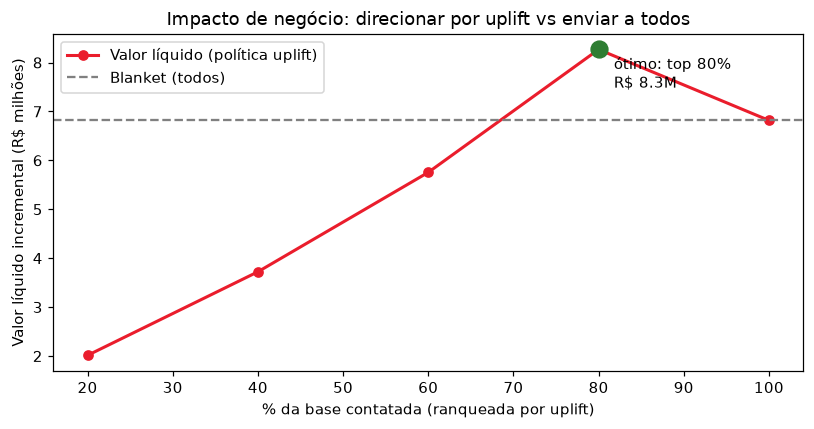

In [12]:
# gráfico de valor líquido incremental por estratégia
plot_df = imp[imp['estratégia'].str.startswith('Uplift')]
fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(plot_df.frac*100, plot_df.net/1e6, 'o-', color=IFOOD_RED, lw=2, label='Valor líquido (política uplift)')
blanket = imp[imp['estratégia']=='Blanket (todos)'].net.iloc[0]/1e6
ax.axhline(blanket, ls='--', color='grey', label='Blanket (todos)')
best = plot_df.loc[plot_df.net.idxmax()]
ax.scatter([best.frac*100],[best.net/1e6], s=120, color='#2E7D32', zorder=5)
ax.annotate(f'ótimo: top {int(best.frac*100)}%\nR$ {best.net/1e6:.1f}M',
            (best.frac*100, best.net/1e6), textcoords='offset points', xytext=(10,-25))
ax.set_xlabel('% da base contatada (ranqueada por uplift)')
ax.set_ylabel('Valor líquido incremental (R$ milhões)')
ax.set_title('Impacto de negócio: direcionar por uplift vs enviar a todos')
ax.legend(); plt.tight_layout(); plt.savefig(FIG/'04_business_impact.png', bbox_inches='tight'); plt.show()

## 7. Conclusões
- O **T-learner supera** o S-learner e o aleatório em Qini-AUC/uplift@k: o ranking
  de uplift concentra as conclusões *incrementais* no topo da base.
- **Direcionar por uplift** captura a maior parte do valor incremental contatando
  uma fração da base, **reduzindo recompensa desperdiçada** (as ~9% de conclusões
  sem visualização) e o custo de mídia.
- A **política de oferta por cliente** favorece *discount* sobre *bogo* (uplift
  muito maior) e evita enviar a quem completaria de qualquer forma.

### Próximos passos
1. Rodar um **A/B test** com grupo de controle real (holdout sem oferta) para
   validar o uplift fora do quase-experimento visto/não-visto.
2. Features pré-oferta (janela anterior) para eliminar o vazamento residual.
3. Otimização de **timing e canal** (dado que canais e duração já entram no modelo).
4. Restrição de orçamento: resolver a alocação como *knapsack* de uplift/custo.
